# Chagas Detection using 12-lead logistic regression approach

### Import libraries

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd
from pandas.plotting import scatter_matrix
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix,  ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.model_selection import learning_curve
from sklearn.decomposition import PCA
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
SEED = 54321

### Loading the data

In [3]:
# Load CSVs into DataFrame
samitrop_df = pd.read_csv('data/samitrop_12_lead_vars.csv')
code15_1_df = pd.read_csv('data/code15_part1_12_lead_vars.csv')

In [4]:
# Clearing the unnecessary index column 
samitrop_df = samitrop_df.drop(['Unnamed: 0','Dataset'], axis=1)
code15_1_df = code15_1_df.drop(['Unnamed: 0','Dataset'], axis=1)

### Handling NULL and blank values for SaMi-Trop

In [5]:
# Dropping the columns that have lots of invalid data
samitrop_df_test = samitrop_df.drop(['L4_std_hr','L4_r_r_var','L4_qt_len','L7_std_hr','L7_r_r_var', 'L7_qt_len','L9_qt_len','L10_qt_len','L11_qt_len','L12_qt_len'], axis=1)

In [6]:
# Get column titles for samitrop dataframe
columns = list(samitrop_df_test)
samitrop_df_test_empty = samitrop_df_test.isna()
# Loop through columns to look for empty or null values
null_list = []
empty_list = []
for col in columns: 
    null_list.append(samitrop_df_test[samitrop_df_test[col] == '~'].shape[0])
    print(f"{col} --> {samitrop_df_test[samitrop_df_test[col] == '~'].shape[0]}")
    empty_list.append(samitrop_df_test_empty[samitrop_df_test_empty[col] == True].shape[0])
    print(f"Empty rows --> {samitrop_df_test_empty[samitrop_df_test_empty[col] == True].shape[0]}")

Chagas label --> 0
Empty rows --> 0
avg_hr_12_leads --> 0
Empty rows --> 0
avg_r_r_dist_12_leads --> 0
Empty rows --> 0
L1_std_hr --> 1
Empty rows --> 0
L1_r_r_var --> 1
Empty rows --> 0
L1_qt_len --> 1
Empty rows --> 18
L2_std_hr --> 26
Empty rows --> 0
L2_r_r_var --> 26
Empty rows --> 0
L2_qt_len --> 26
Empty rows --> 12
L3_std_hr --> 22
Empty rows --> 0
L3_r_r_var --> 22
Empty rows --> 0
L3_qt_len --> 22
Empty rows --> 23
L5_std_hr --> 2
Empty rows --> 0
L5_r_r_var --> 2
Empty rows --> 0
L5_qt_len --> 2
Empty rows --> 37
L6_std_hr --> 20
Empty rows --> 0
L6_r_r_var --> 20
Empty rows --> 0
L6_qt_len --> 20
Empty rows --> 16
L8_std_hr --> 22
Empty rows --> 0
L8_r_r_var --> 22
Empty rows --> 0
L8_qt_len --> 22
Empty rows --> 38
L9_std_hr --> 26
Empty rows --> 0
L9_r_r_var --> 26
Empty rows --> 0
L10_std_hr --> 17
Empty rows --> 0
L10_r_r_var --> 17
Empty rows --> 0
L11_std_hr --> 10
Empty rows --> 0
L11_r_r_var --> 10
Empty rows --> 0
L12_std_hr --> 9
Empty rows --> 0
L12_r_r_var --> 9

In [7]:
def is_blank_row(row):
    # print(f"row = {list(row)}")
    # print(row.isna())
    for val in list(row):
        if ((pd.isna(val) == True) or (val == '~')):
            return True
    return False

blank_row_list = list(samitrop_df_test.loc[:,:].apply(is_blank_row, axis=1))
print(f"Complete rows = {blank_row_list.count(False)}")
print(f"Incomplete rows = {blank_row_list.count(True)}")
print(blank_row_list.count(True)/len(blank_row_list))

Complete rows = 1475
Incomplete rows = 156
0.0956468424279583


In [8]:
# Creating list of the rows with invalid values
index_list = []
for i in range(len(blank_row_list)):
    if (blank_row_list[i] == True):
        index_list.append(i)
index_list

[4,
 7,
 11,
 23,
 24,
 30,
 33,
 39,
 40,
 45,
 66,
 68,
 74,
 80,
 98,
 111,
 112,
 114,
 118,
 129,
 145,
 148,
 151,
 160,
 191,
 199,
 203,
 206,
 209,
 218,
 226,
 228,
 240,
 244,
 248,
 254,
 255,
 257,
 280,
 286,
 338,
 378,
 392,
 393,
 417,
 429,
 436,
 457,
 464,
 466,
 474,
 497,
 501,
 513,
 526,
 530,
 561,
 566,
 569,
 576,
 587,
 596,
 611,
 631,
 633,
 634,
 638,
 662,
 664,
 665,
 707,
 732,
 733,
 757,
 773,
 781,
 782,
 787,
 816,
 825,
 847,
 852,
 858,
 871,
 872,
 877,
 880,
 891,
 896,
 899,
 908,
 911,
 924,
 931,
 934,
 940,
 964,
 966,
 982,
 992,
 1004,
 1010,
 1016,
 1030,
 1031,
 1040,
 1050,
 1054,
 1055,
 1056,
 1128,
 1179,
 1200,
 1203,
 1245,
 1274,
 1279,
 1301,
 1312,
 1318,
 1328,
 1344,
 1348,
 1353,
 1359,
 1364,
 1377,
 1387,
 1390,
 1398,
 1405,
 1407,
 1410,
 1411,
 1441,
 1450,
 1456,
 1472,
 1473,
 1478,
 1479,
 1481,
 1485,
 1491,
 1492,
 1534,
 1538,
 1548,
 1564,
 1566,
 1570,
 1571,
 1589,
 1610,
 1615,
 1620]

In [9]:
# Drop rows with invalid values from dataframe
samitrop_df_test = samitrop_df_test.drop(index_list)

In [10]:
# Reset the index values for the dataframe
samitrop_df_test = samitrop_df_test.reset_index(drop=True)

### Handling NULL and blank values for CODE-15%

In [11]:
# Get column titles for code15 dataframe
columns = list(code15_1_df)
code15_1_df_empty = code15_1_df.isna()
# Loop through columns to look for empty or null values
null_list = []
empty_list = []
for col in columns: 
    null_list.append(code15_1_df[code15_1_df[col] == '~'].shape[0])
    print(f"{col} --> {code15_1_df[code15_1_df[col] == '~'].shape[0]}")
    empty_list.append(code15_1_df_empty[code15_1_df_empty[col] == True].shape[0])
    print(f"Empty rows --> {code15_1_df_empty[code15_1_df_empty[col] == True].shape[0]}")

Chagas label --> 0
Empty rows --> 53
avg_hr_12_leads --> 0
Empty rows --> 63
avg_r_r_dist_12_leads --> 0
Empty rows --> 63
L1_std_hr --> 81
Empty rows --> 0
L1_r_r_var --> 81
Empty rows --> 0
L1_qt_len --> 81
Empty rows --> 115
L2_std_hr --> 104
Empty rows --> 0
L2_r_r_var --> 104
Empty rows --> 0
L2_qt_len --> 104
Empty rows --> 100
L3_std_hr --> 153
Empty rows --> 0
L3_r_r_var --> 153
Empty rows --> 0
L3_qt_len --> 153
Empty rows --> 141
L4_std_hr --> 190
Empty rows --> 0
L4_r_r_var --> 190
Empty rows --> 0
L4_qt_len --> 190
Empty rows --> 1222
L5_std_hr --> 92
Empty rows --> 0
L5_r_r_var --> 92
Empty rows --> 0
L5_qt_len --> 92
Empty rows --> 210
L6_std_hr --> 129
Empty rows --> 0
L6_r_r_var --> 129
Empty rows --> 0
L6_qt_len --> 129
Empty rows --> 111
L7_std_hr --> 186
Empty rows --> 0
L7_r_r_var --> 186
Empty rows --> 0
L7_qt_len --> 186
Empty rows --> 376
L8_std_hr --> 142
Empty rows --> 0
L8_r_r_var --> 142
Empty rows --> 0
L8_qt_len --> 142
Empty rows --> 267
L9_std_hr --> 134


In [12]:
null_list.sort()
print(null_list)

[0, 0, 0, 81, 81, 81, 92, 92, 92, 104, 104, 104, 108, 108, 108, 116, 116, 116, 123, 123, 123, 129, 129, 129, 134, 134, 134, 142, 142, 142, 153, 153, 153, 186, 186, 186, 190, 190, 190]


In [13]:
empty_list.sort()
print(empty_list)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 53, 63, 63, 100, 111, 115, 141, 210, 267, 345, 376, 423, 622, 635, 1222]


In [14]:
empty_chagas_labels = code15_1_df_empty[code15_1_df_empty['Chagas label'] == True].index

In [15]:
code15_1_df_test = code15_1_df.drop(['L4_std_hr','L4_r_r_var','L4_qt_len','L7_std_hr','L7_r_r_var', 'L7_qt_len','L9_qt_len','L10_qt_len','L11_qt_len','L12_qt_len'], axis=1)
code15_1_df_test = code15_1_df_test.drop(empty_chagas_labels)

In [16]:
# Changing datatype of Chagas label column from object to bool in code15_1_df_test
code15_1_df_test['Chagas label'] = code15_1_df_test['Chagas label'].apply(bool)

In [17]:
code15_1_df_test = code15_1_df_test.reset_index(drop=True)

In [18]:
def is_blank_row(row):
    # print(f"row = {list(row)}")
    # print(row.isna())
    for val in list(row):
        if ((pd.isna(val) == True) or (val == '~')):
            return True
    return False

blank_row_list = list(code15_1_df_test.loc[:,:].apply(is_blank_row, axis=1))
print(f"Complete rows = {blank_row_list.count(False)}")
print(f"Incomplete rows = {blank_row_list.count(True)}")
print(blank_row_list.count(True)/len(blank_row_list))

Complete rows = 18982
Incomplete rows = 966
0.04842590735913375


In [19]:
index_list = []
for i in range(len(blank_row_list)):
    if (blank_row_list[i] == True):
        index_list.append(i)
index_list

[34,
 59,
 60,
 69,
 117,
 136,
 149,
 178,
 179,
 180,
 184,
 188,
 230,
 242,
 293,
 335,
 353,
 387,
 404,
 409,
 422,
 474,
 486,
 507,
 523,
 539,
 576,
 593,
 594,
 606,
 737,
 754,
 764,
 775,
 782,
 785,
 788,
 822,
 867,
 876,
 879,
 880,
 903,
 944,
 963,
 991,
 1015,
 1037,
 1051,
 1053,
 1163,
 1179,
 1206,
 1219,
 1252,
 1269,
 1302,
 1329,
 1337,
 1347,
 1382,
 1416,
 1439,
 1488,
 1489,
 1490,
 1591,
 1608,
 1609,
 1655,
 1726,
 1735,
 1751,
 1760,
 1766,
 1824,
 1850,
 1855,
 1861,
 1884,
 1906,
 2002,
 2059,
 2065,
 2077,
 2091,
 2113,
 2131,
 2144,
 2154,
 2163,
 2303,
 2310,
 2340,
 2364,
 2369,
 2374,
 2382,
 2418,
 2423,
 2486,
 2487,
 2535,
 2541,
 2548,
 2564,
 2578,
 2586,
 2596,
 2602,
 2603,
 2604,
 2622,
 2654,
 2662,
 2690,
 2701,
 2721,
 2757,
 2778,
 2786,
 2832,
 2851,
 2877,
 2920,
 2922,
 2972,
 3004,
 3029,
 3046,
 3055,
 3103,
 3104,
 3105,
 3139,
 3193,
 3198,
 3347,
 3356,
 3369,
 3395,
 3403,
 3440,
 3443,
 3470,
 3478,
 3484,
 3563,
 3567,
 3585,


In [20]:
code15_1_df_test = code15_1_df_test.drop(index_list)

In [21]:
code15_1_df_test = code15_1_df_test.reset_index(drop=True)

In [22]:
# Confirming that our test dataframe has NO null or empty values
columns = list(code15_1_df_test)
code15_1_df_test_empty = code15_1_df_test.isna()
# Loop through columns to look for empty or null values
null_list = []
empty_list = []
for col in columns: 
    null_list.append(code15_1_df_test[code15_1_df_test[col] == '~'].shape[0])
    print(f"{col} --> {code15_1_df_test[code15_1_df_test[col] == '~'].shape[0]}")
    empty_list.append(code15_1_df_test_empty[code15_1_df_test_empty[col] == True].shape[0])
    print(f"Empty rows --> {code15_1_df_test_empty[code15_1_df_test_empty[col] == True].shape[0]}")

Chagas label --> 0
Empty rows --> 0
avg_hr_12_leads --> 0
Empty rows --> 0
avg_r_r_dist_12_leads --> 0
Empty rows --> 0
L1_std_hr --> 0
Empty rows --> 0
L1_r_r_var --> 0
Empty rows --> 0
L1_qt_len --> 0
Empty rows --> 0
L2_std_hr --> 0
Empty rows --> 0
L2_r_r_var --> 0
Empty rows --> 0
L2_qt_len --> 0
Empty rows --> 0
L3_std_hr --> 0
Empty rows --> 0
L3_r_r_var --> 0
Empty rows --> 0
L3_qt_len --> 0
Empty rows --> 0
L5_std_hr --> 0
Empty rows --> 0
L5_r_r_var --> 0
Empty rows --> 0
L5_qt_len --> 0
Empty rows --> 0
L6_std_hr --> 0
Empty rows --> 0
L6_r_r_var --> 0
Empty rows --> 0
L6_qt_len --> 0
Empty rows --> 0
L8_std_hr --> 0
Empty rows --> 0
L8_r_r_var --> 0
Empty rows --> 0
L8_qt_len --> 0
Empty rows --> 0
L9_std_hr --> 0
Empty rows --> 0
L9_r_r_var --> 0
Empty rows --> 0
L10_std_hr --> 0
Empty rows --> 0
L10_r_r_var --> 0
Empty rows --> 0
L11_std_hr --> 0
Empty rows --> 0
L11_r_r_var --> 0
Empty rows --> 0
L12_std_hr --> 0
Empty rows --> 0
L12_r_r_var --> 0
Empty rows --> 0


In [23]:
# Finding NULL values from the dataset, these values presented an error earlier when compiling the info for the data
code15_1_df[code15_1_df['avg_hr_12_leads'] == '~'].shape

(0, 39)

### Looking at the details for the dataframes

In [24]:
# Print sizes for the samitrop and the code15 dataframe
print(samitrop_df.shape)
print(code15_1_df.shape)

(1631, 39)
(20001, 39)


In [25]:
samitrop_df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Chagas label           1475 non-null   bool   
 1   avg_hr_12_leads        1475 non-null   float64
 2   avg_r_r_dist_12_leads  1475 non-null   float64
 3   L1_std_hr              1475 non-null   object 
 4   L1_r_r_var             1475 non-null   object 
 5   L1_qt_len              1475 non-null   object 
 6   L2_std_hr              1475 non-null   object 
 7   L2_r_r_var             1475 non-null   object 
 8   L2_qt_len              1475 non-null   object 
 9   L3_std_hr              1475 non-null   object 
 10  L3_r_r_var             1475 non-null   object 
 11  L3_qt_len              1475 non-null   object 
 12  L5_std_hr              1475 non-null   object 
 13  L5_r_r_var             1475 non-null   object 
 14  L5_qt_len              1475 non-null   object 
 15  L6_s

In [26]:
code15_1_df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18982 entries, 0 to 18981
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Chagas label           18982 non-null  bool   
 1   avg_hr_12_leads        18982 non-null  float64
 2   avg_r_r_dist_12_leads  18982 non-null  float64
 3   L1_std_hr              18982 non-null  object 
 4   L1_r_r_var             18982 non-null  object 
 5   L1_qt_len              18982 non-null  object 
 6   L2_std_hr              18982 non-null  object 
 7   L2_r_r_var             18982 non-null  object 
 8   L2_qt_len              18982 non-null  object 
 9   L3_std_hr              18982 non-null  object 
 10  L3_r_r_var             18982 non-null  object 
 11  L3_qt_len              18982 non-null  object 
 12  L5_std_hr              18982 non-null  object 
 13  L5_r_r_var             18982 non-null  object 
 14  L5_qt_len              18982 non-null  object 
 15  L6

### Separating the data into train and test splits

In [27]:
# Separating the SaMi-Trop dataset into train and test splits
st_data = samitrop_df_test.drop(['Chagas label'], axis=1)
st_label = samitrop_df_test['Chagas label']
st_X_train, st_X_test, st_y_train, st_y_test = train_test_split(st_data, st_label, test_size=0.25, random_state=SEED)

In [28]:
# Separating the CODE-15% dataset into train and test splits
c15_data = code15_1_df_test.drop(['Chagas label'], axis=1)
c15_label = code15_1_df_test['Chagas label']
c15_X_train, c15_X_test, c15_y_train, c15_y_test = train_test_split(c15_data, c15_label, test_size=0.25, random_state=SEED)

In [29]:
# Merging the datasets into the final train and test splits
X_train = pd.concat([c15_X_train, st_X_train], axis=0)
X_test = pd.concat([c15_X_test, st_X_test], axis=0)
y_train = pd.concat([c15_y_train, st_y_train], axis=0)
y_test = pd.concat([c15_y_test, st_y_test], axis=0)

In [30]:
# Scaling the training and test data
scaler = StandardScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### Analyzing class counts in training data

In [31]:
# Converting the Chagas labels into a 0 or 1 (binary) list for ease of processing
y_train_binary = []
for y in y_train:
    if y == False:
        y_train_binary.append(0)
    else:
        y_train_binary.append(1)

In [32]:
# Printing out counts that will be used in the class_weights variable below
print(f"False labels: {y_train_binary.count(0)}")
false_labels = y_train_binary.count(0)
print(f"True labels: {y_train_binary.count(1)}")
true_labels = y_train_binary.count(1)
print(f"Total = {len(y_train_binary)}")
total_labels = len(y_train_binary)

False labels: 14518
True labels: 824
Total = 15342


## Using class weights when training the model

In [33]:
# Preparing class weights to help balance the model
class_weights = {0: total_labels/(2*false_labels), 1: total_labels/(2*true_labels)}

### Training the model

In [34]:
# Hyperparameters to tune the logistic regression modeld
param_grid = {'penalty': ['l2', None], 'C':[0.0001,0.001,0.01,0.1,1,10], 'solver':['saga']}

In [37]:
# Convert y_train into DataFrame object for use in fitting the model
y_train = pd.DataFrame(y_train)

# Parameter for how to balance the grid search scoring system
score='balanced_accuracy'

# Declaring our initial model object
model_lr = LogisticRegression(class_weight=class_weights, random_state=SEED)

print(f'Tuning logistic regression ...........................')
# create a GridSearchCV object for this model
grid_search = GridSearchCV(model_lr, param_grid, cv=5, scoring=score, refit=True, n_jobs=-1, error_score='raise')
grid_search.fit(X_train_scaled, y_train)
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best validation score: {grid_search.best_score_}')

Tuning logistic regression ...........................
Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Best validation score: 0.5876696751714701


### Plotting model metrics

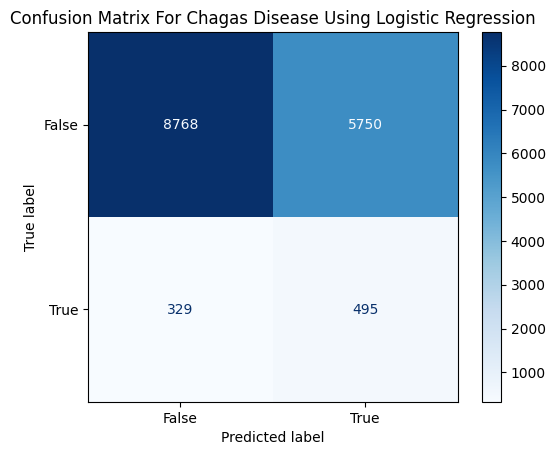

In [38]:
# first we need the model predictions 
predictions = grid_search.predict(X_train_scaled)

# next we can use the confusion_matrix function to get the confusion matrix
cm = confusion_matrix(y_train, predictions)

# we can use the ConfusionMatrixDisplay to plot the confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels=['False', 'True'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix For Chagas Disease Using Logistic Regression')
plt.show()

In [39]:
print(classification_report(y_train, predictions, target_names=['False', 'True']))

              precision    recall  f1-score   support

       False       0.96      0.60      0.74     14518
        True       0.08      0.60      0.14       824

    accuracy                           0.60     15342
   macro avg       0.52      0.60      0.44     15342
weighted avg       0.92      0.60      0.71     15342



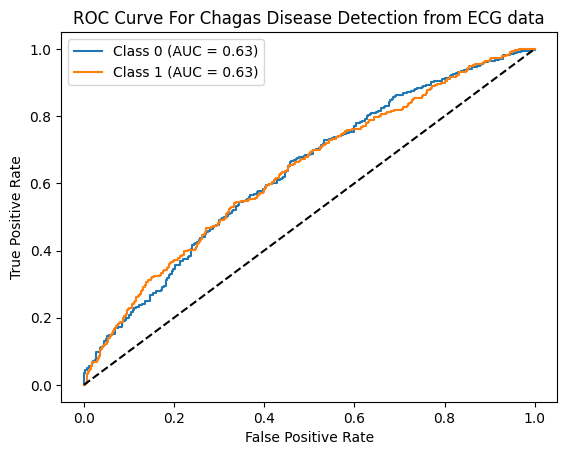

In [40]:
probs = grid_search.predict_proba(X_test_scaled)
fpr = dict()
tpr = dict()
roc_auc = {0:0, 1:0}
for i in range(2):
    fpr[i], tpr[i], _ = roc_curve(y_test, probs[:, i], pos_label=i)
    y_test_i = np.array(y_test == i).astype(int)
    roc_auc[i] = roc_auc_score(y_test_i, probs[:, i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve For Chagas Disease Detection from ECG data')
plt.legend()
plt.show()

## Using SMOTE when training the model

### Installing necessary libraries

In [41]:
pip install imbalanced-learn


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [42]:
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

### Training the model

In [43]:
# Hyperparameters to tune the logistic regression modeld
param_grid = {'o__sampling_strategy': [0.5,0.75,1],'model__penalty': ['l2', None], 'model__C':[0.0001,0.001,0.01,0.1,1,10], 'model__solver':['saga']}

In [44]:
over = BorderlineSMOTE()
model_pip = Pipeline([('o',over),('model', LogisticRegression(random_state=SEED))])
score = 'f1'

grid_search = GridSearchCV(model_pip, param_grid, cv=5, scoring=score, refit=True, n_jobs=-1, error_score='raise')

grid_search.fit(X_train_scaled, y_train)
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best validation score: {grid_search.best_score_}')

Best parameters: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'saga', 'o__sampling_strategy': 0.75}
Best validation score: 0.14216481057018288


### Plotting model metrics

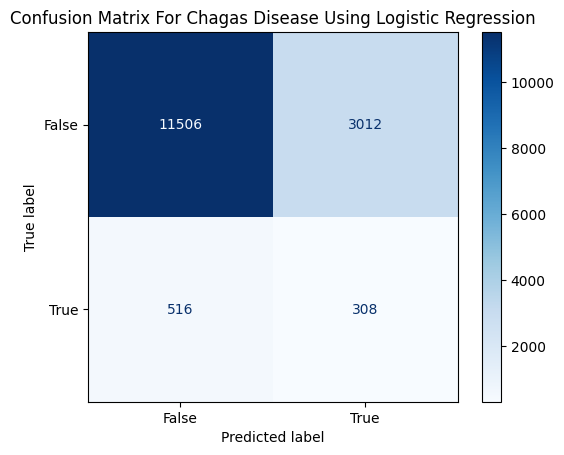

In [45]:
# first we need the model predictions 
predictions = grid_search.predict(X_train_scaled)

# next we can use the confusion_matrix function to get the confusion matrix
cm = confusion_matrix(y_train, predictions)

# we can use the ConfusionMatrixDisplay to plot the confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels=['False', 'True'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix For Chagas Disease Using Logistic Regression')
plt.show()

In [46]:
print(classification_report(y_train, predictions, target_names=['False', 'True']))

              precision    recall  f1-score   support

       False       0.96      0.79      0.87     14518
        True       0.09      0.37      0.15       824

    accuracy                           0.77     15342
   macro avg       0.52      0.58      0.51     15342
weighted avg       0.91      0.77      0.83     15342



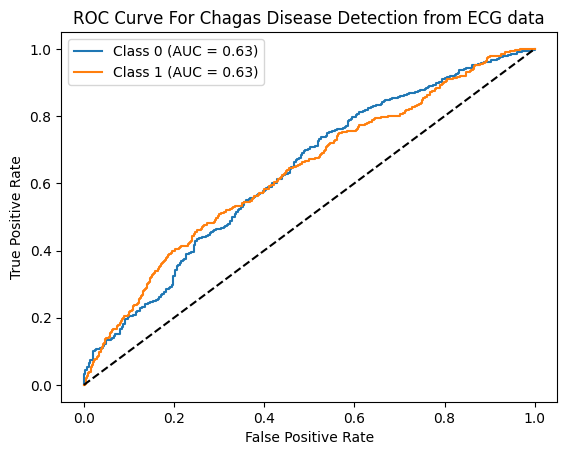

In [47]:
probs = grid_search.predict_proba(X_test_scaled)
fpr = dict()
tpr = dict()
roc_auc = {0:0, 1:0}
for i in range(2):
    fpr[i], tpr[i], _ = roc_curve(y_test, probs[:, i], pos_label=i)
    y_test_i = np.array(y_test == i).astype(int)
    roc_auc[i] = roc_auc_score(y_test_i, probs[:, i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve For Chagas Disease Detection from ECG data')
plt.legend()
plt.show()